In [56]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
import geopandas as gpd
import os
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.cluster import KMeans
import random


In [57]:
os.chdir("C:/Users/fabia/Documents/#Köln/Uni/Semester 3/SusDev/DietOnEmissions")
df = pd.read_csv("data/food_wide.csv")
df = df.drop("animal_share", axis=1)
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

In [58]:
exclude = ["iso3c", "Area", "Year"]
food_cols = [c for c in df.columns if c not in exclude]

# convert to shares of grand total
df_shares = df.copy()
for c in food_cols:
     if c != "Grand Total":
        df_shares[c] = df_shares[c] / df_shares["Grand Total"]

df_shares[food_cols] = df_shares[food_cols].fillna(0)


In [59]:
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_shares[food_cols])

df_scaled = df_shares.copy()
for i, c in enumerate(food_cols):
    df_scaled[c] = scaled_values[:, i]

In [60]:
X = df_scaled[food_cols].values
"""
ks = range(1, 300)
inertias = []

for k in ks:
    kmeans = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=SEED
    )
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(ks, inertias, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow Method for Optimal k")
plt.tight_layout()

plt.savefig("plots/elbow_plot.pdf", format="pdf", bbox_inches="tight")
plt.show()
"""

'\nks = range(1, 300)\ninertias = []\n\nfor k in ks:\n    kmeans = KMeans(\n        n_clusters=k,\n        n_init=10,\n        random_state=SEED\n    )\n    kmeans.fit(X)\n    inertias.append(kmeans.inertia_)\n\nplt.figure(figsize=(6, 4))\nplt.plot(ks, inertias, marker="o")\nplt.xlabel("Number of clusters k")\nplt.ylabel("Inertia (within-cluster sum of squares)")\nplt.title("Elbow Method for Optimal k")\nplt.tight_layout()\n\nplt.savefig("plots/elbow_plot.pdf", format="pdf", bbox_inches="tight")\nplt.show()\n'

In [61]:
Z = linkage(df_scaled[food_cols], method="ward")

k = 15
cluster_labels = fcluster(Z, t=k, criterion="maxclust")

# Attach clusters back to data
df_clusters = df_shares.copy()
df_clusters["cluster"] = cluster_labels
"""
plt.figure(figsize=(14, 6))
dendrogram(Z, labels=df_scaled["Area"].values, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (Ward linkage)")
plt.tight_layout()
plt.show()
"""

'\nplt.figure(figsize=(14, 6))\ndendrogram(Z, labels=df_scaled["Area"].values, leaf_rotation=90)\nplt.title("Hierarchical Clustering Dendrogram (Ward linkage)")\nplt.tight_layout()\nplt.show()\n'

In [72]:
world = gpd.read_file("data/ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp")

name_fix = {
    "Russian Federation": "Russia",
    "Democratic Republic of the Congo": "Dem. Rep. Congo",
    "Iran (Islamic Republic of)": "Iran",
    "Viet Nam": "Vietnam",
    "Ivory Coast": "Côte d'Ivoire",
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "China, Taiwan Province of": "Taiwan",
    "Eswatini": "eSwatini",
    "Netherlands (Kingdom of the)": "Netherlands",
    "Republic of Korea": "South Korea",
    "Türkiye": "Turkey",
    "Bosnia and Herzegovina": "Bosnia and Herz.",
    "Democratic People's Republic of Korea": "North Korea",
    'Venezuela (Bolivarian Republic of)': "Venezuela",
    "Syrian Arab Republic": "Syria",
    "Republic of Moldova": "Moldova",
    "Lao People's Democratic Republic": "Laos",
    "Solomon Islands": "Solomon Is.",
    "United Republic of Tanzania": "Tanzania",
    "Bolivia (Plurinational State of)": "Bolivia",
    "Dominican Republic": "Dominican Rep.",
    "China, Hong Kong SAR": "Hong Kong",
    "China, Macao SAR": "Macao",
    "Micronesia (Federated States of)": "Micronesia",
    "China, mainland": "China",
    "Marshall Islands": "Marshall Is.",
    'Saint Kitts and Nevis': 'St. Kitts and Nevis',
    'Saint Vincent and the Grenadines': 'St. Vin. and Gren.',
    "Antigua and Barbuda": "Antigua and Barb.",
    "French Polynesia": "Fr. Polynesia",
    "Sao Tome and Principe": "São Tomé and Principe"}


# Apply name mapping
df_clusters["Area_fixed"] = df_clusters["Area"].replace(name_fix)

df_clusters.head()

fix_world_codes = {
    "France": "FRA",
    "Norway": "NOR",
}

world.loc[world["NAME"].isin(fix_world_codes.keys()), "ISO_A3"] = \
    world.loc[world["NAME"].isin(fix_world_codes.keys()), "NAME"].map(fix_world_codes)


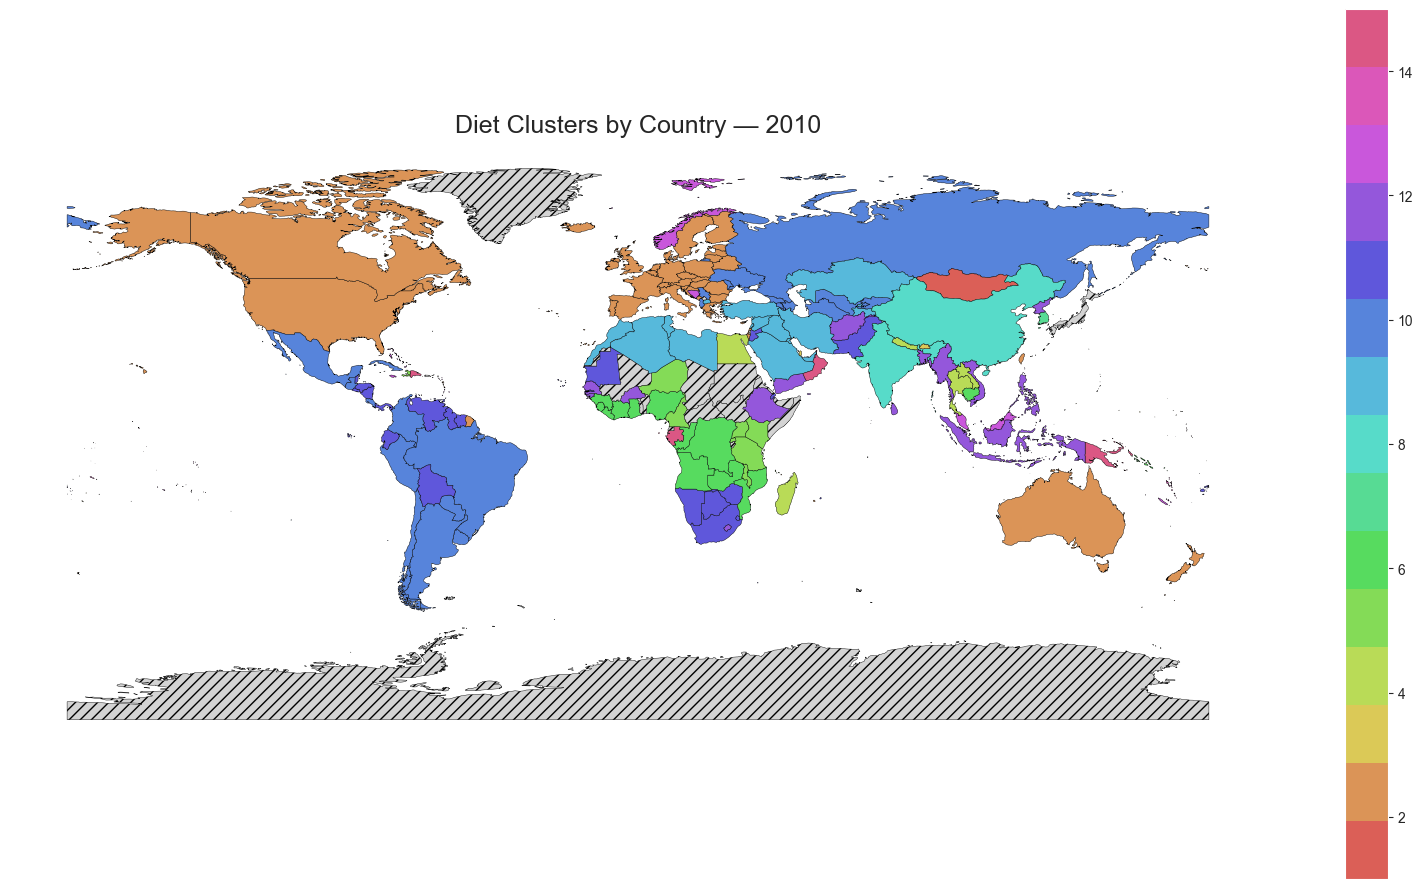

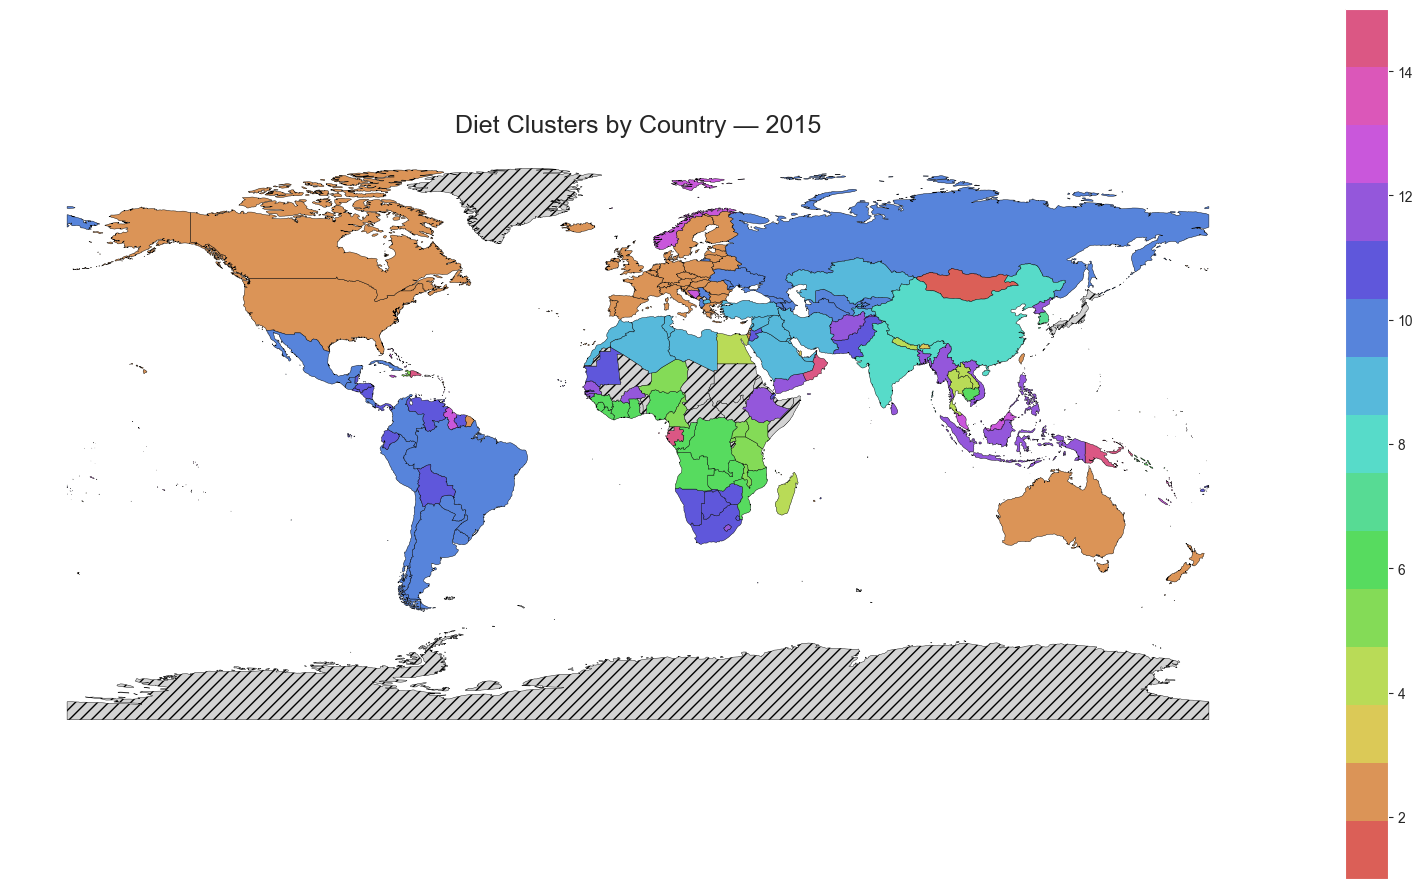

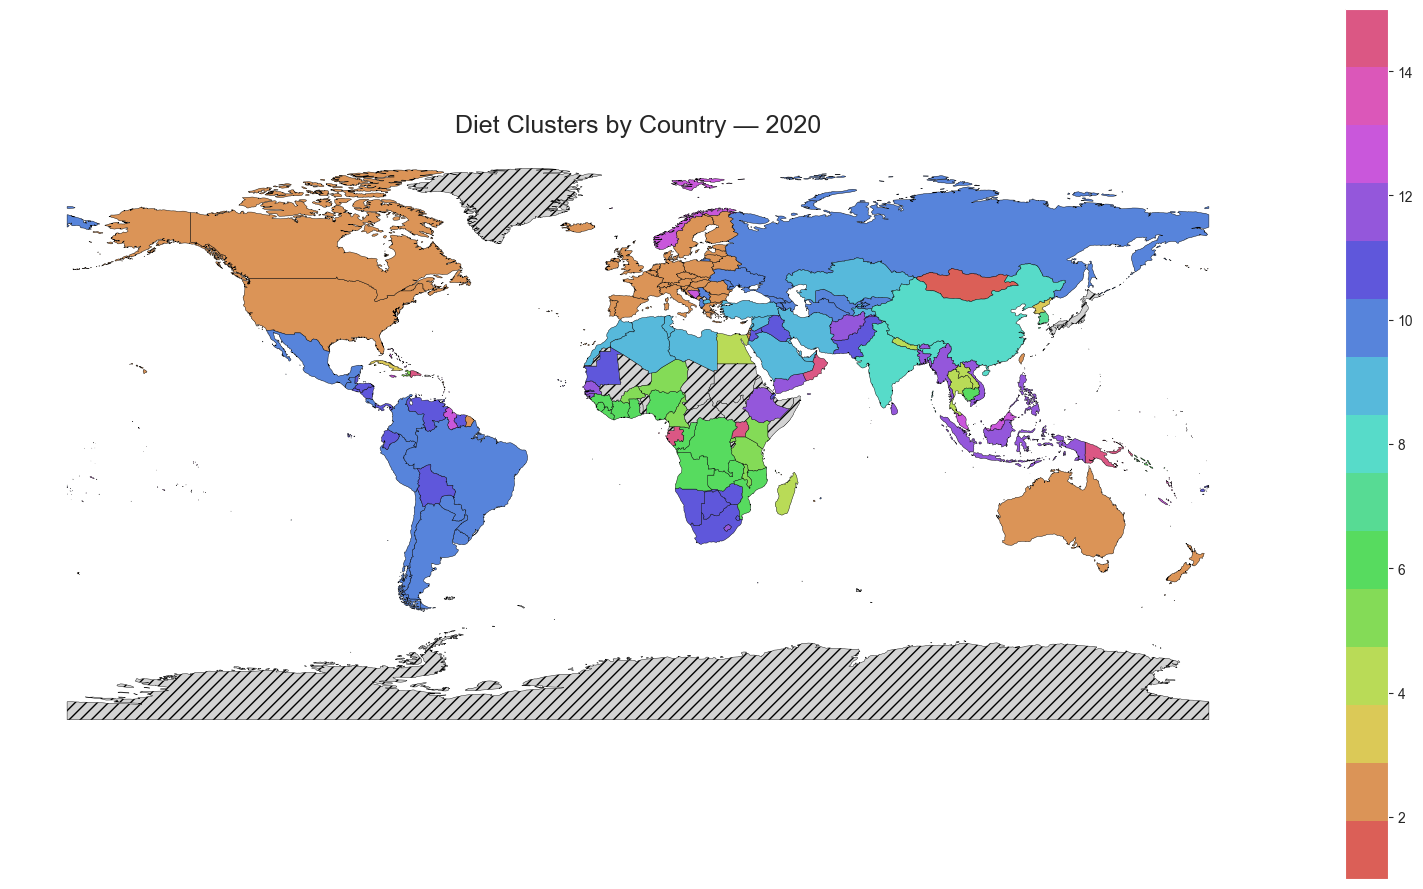

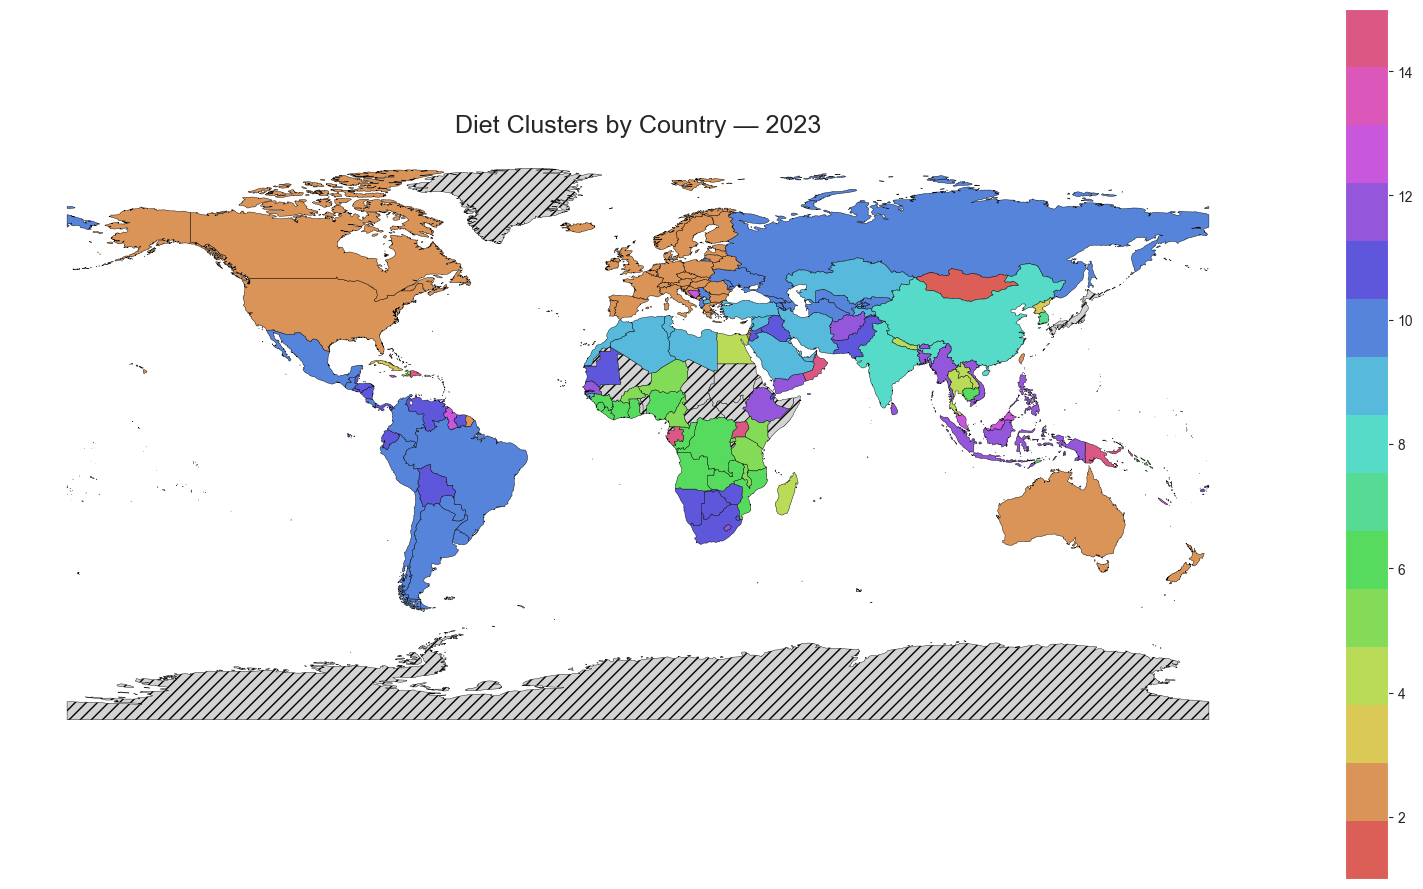

In [95]:
YEARS = [2010, 2015, 2020, 2023]

for YEAR in YEARS:
    df_year = df_clusters[df_clusters["Year"] == YEAR].copy()


    map_df = world.merge(df_year, how="left", left_on="ISO_A3", right_on="iso3c")

    fig, ax = plt.subplots(figsize=(16, 9))
    map_df.plot(column="cluster",
            cmap = ListedColormap(sns.color_palette("hls", 15)),
            legend=True,
            edgecolor="black",
            linewidth=0.3,
            ax=ax,
            missing_kwds={
                "color": "lightgrey",
                "edgecolor": "black",
                "hatch": "///",
                "label": "No data"},)

    ax.set_title(f"Diet Clusters by Country — {YEAR}", fontsize=18)
    ax.axis("off")
    plt.tight_layout()
    fig.savefig(f"plots/diet_clusters_map_{YEAR}.pdf", format="pdf", dpi=300, bbox_inches="tight")
    plt.show()

In [70]:
print(df_clusters["Animal Products"].unique())

[0.09062317 0.08880407 0.09037435 ... 0.17696889 0.17903337 0.17433086]


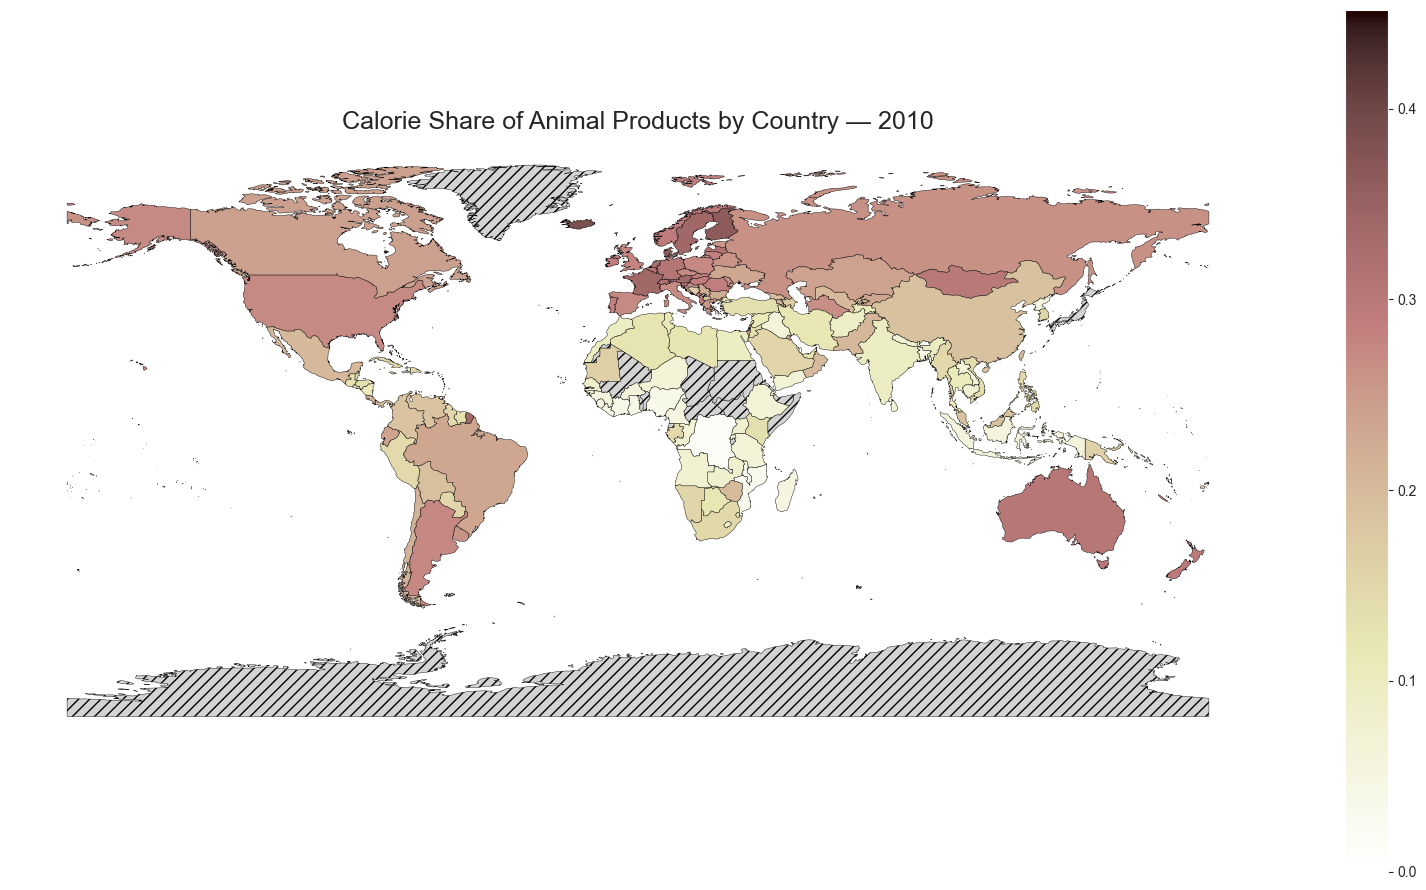

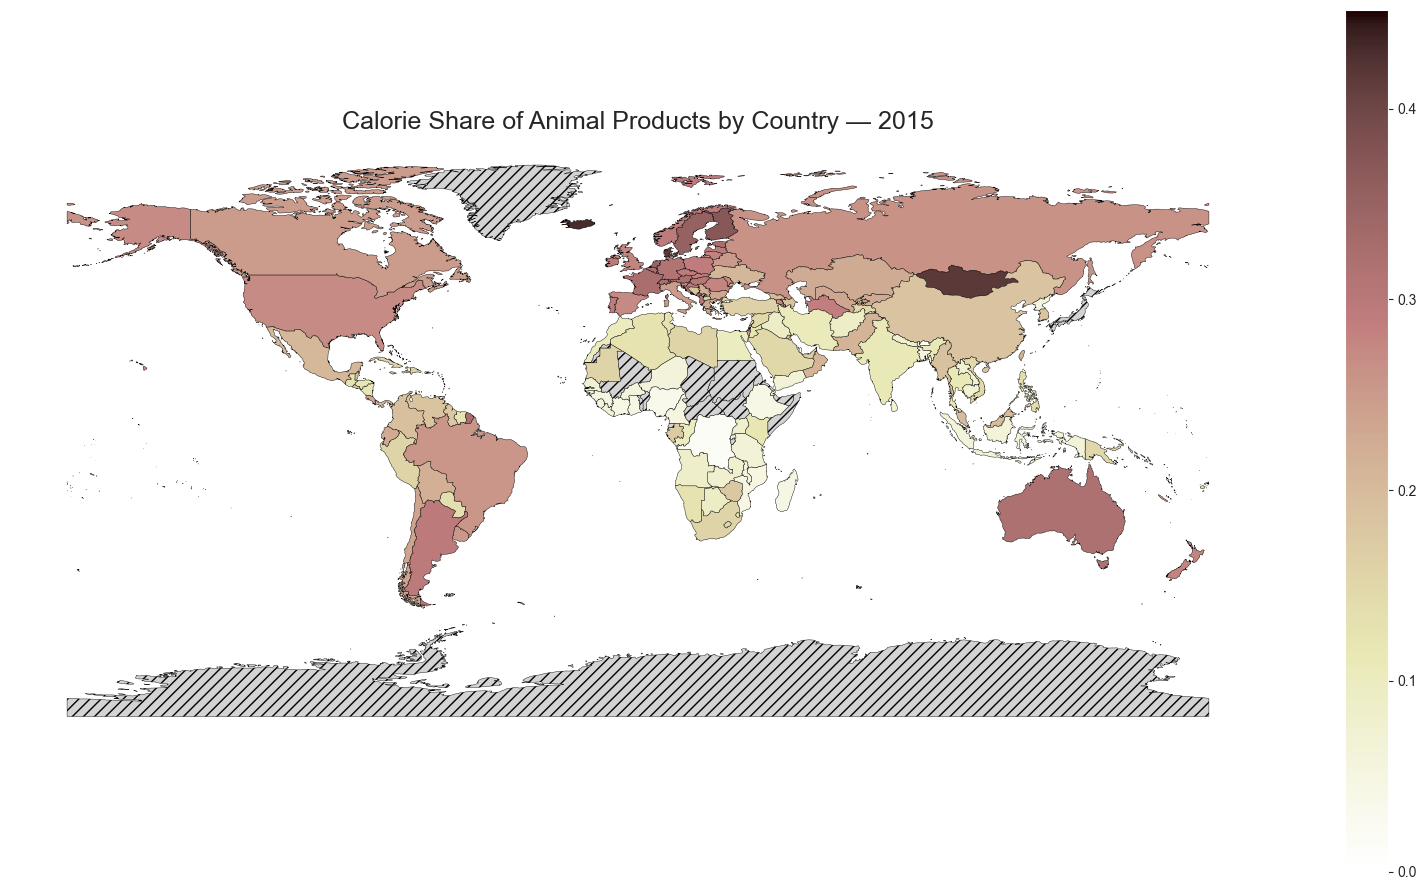

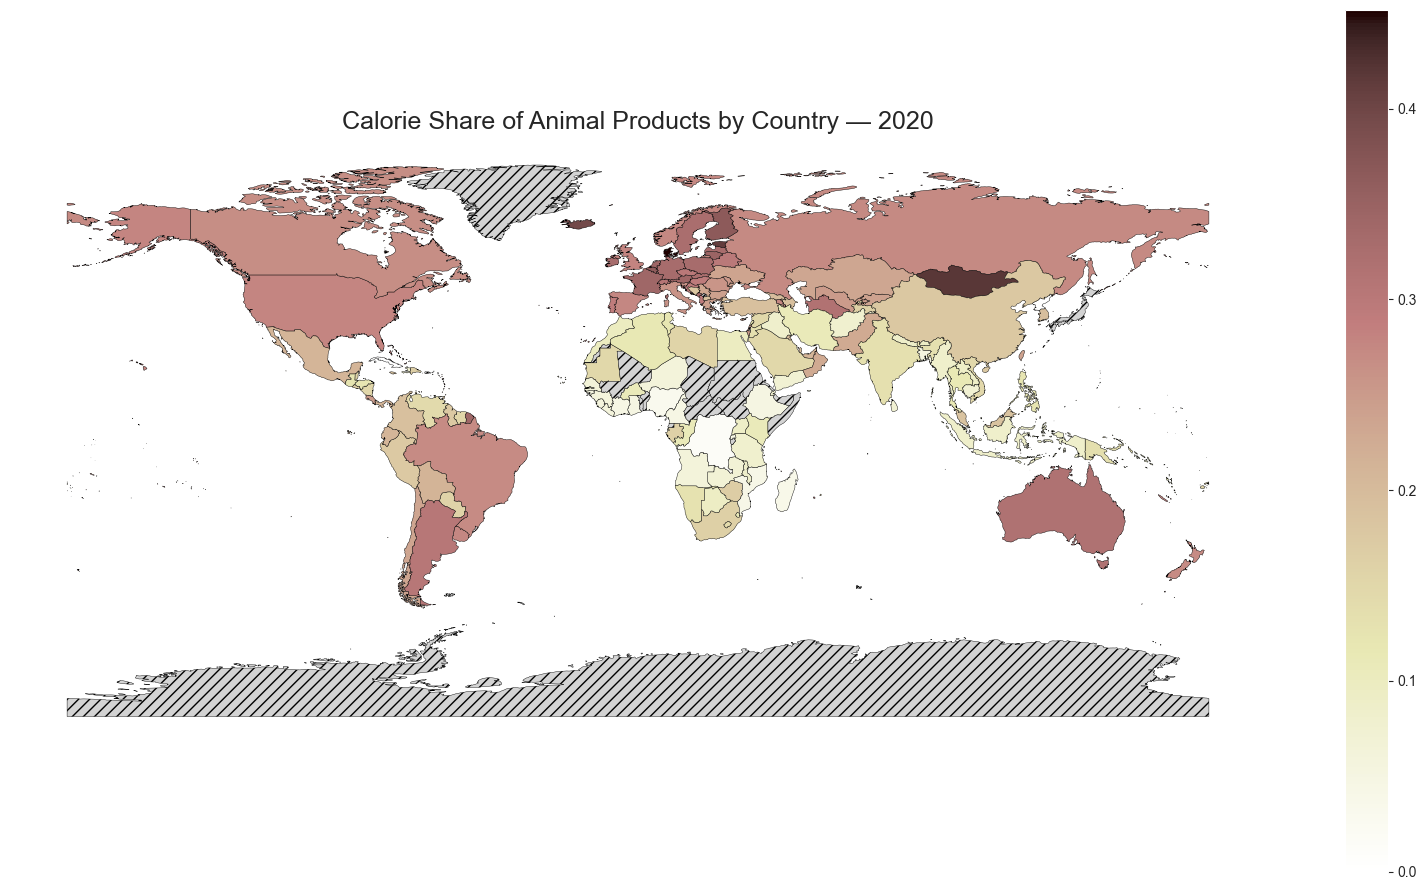

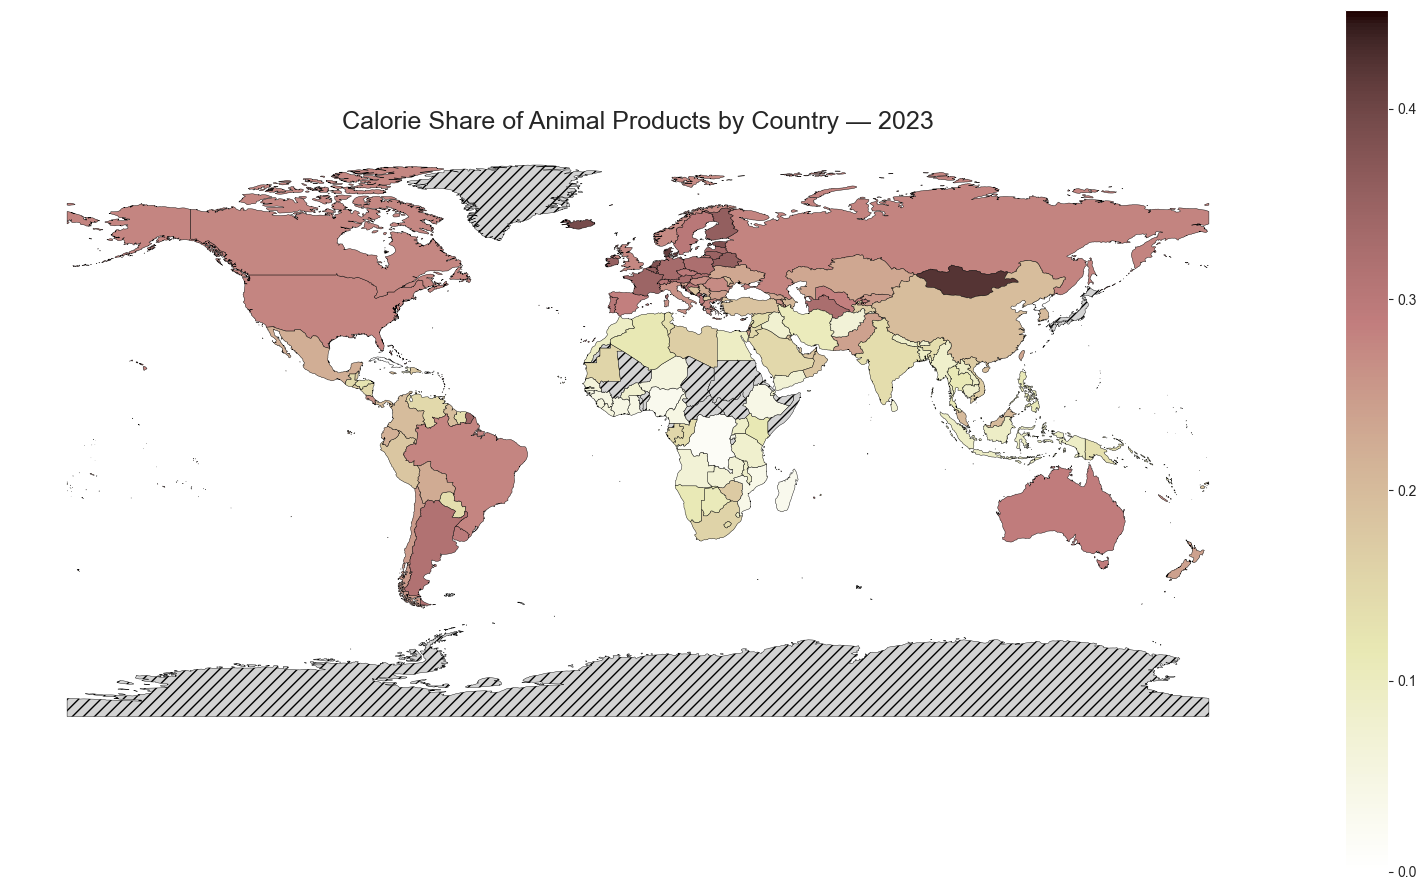

In [90]:
min_animal = 0.0
max_animal = max(df_clusters["Animal Products"])

for YEAR in YEARS:
    df_year = df_clusters[df_clusters["Year"] == YEAR].copy()

    map_df = world.merge(df_year, how="left", left_on="NAME", right_on="Area_fixed")

    fig, ax = plt.subplots(figsize=(16, 9))
    map_df.plot(column="Animal Products",
            #cmap = "seismic",
            cmap = "pink_r",
            vmin=min_animal,
            vmax=max_animal,
            legend=True,
            edgecolor="black",
            linewidth=0.3,
            ax=ax,
            missing_kwds={
                "color": "lightgrey",
                "edgecolor": "black",
                "hatch": "///",
                "label": "No data"},)

    ax.set_title(f"Calorie Share of Animal Products by Country — {YEAR}", fontsize=18)
    ax.axis("off")
    plt.tight_layout()
    fig.savefig(f"plots/animal_share_map_{YEAR}.pdf", format="pdf", dpi=300, bbox_inches="tight")
    plt.show()